load data

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/ipo_data.csv")
print("shape:" , df.shape)
print(df.head(5).to_string())
print(df.info())

Matplotlib is building the font cache; this may take a moment.


shape: (652, 13)
       Date               IPO_Name Issue_Size(crores)    QIB    HNI   RII  Total Offer Price List Price Listing Gain CMP(BSE) CMP(NSE) Current Gains
0  05/14/26  Bagmane Prime Offi...               3405  17.09  15.79  0.00  16.50         100      103.4          3.4   103.92   103.97          3.92
1  05/08/26  Onemi Technology S...             925.92  24.87   6.57  2.03   9.50         171        191         11.7    231.7   231.74          35.5
2  04/29/26  Citius Transnet In...               1105   8.54  11.77  0.00  10.01         100      104.5          4.5   105.87   106.04          5.87
3  04/17/26  Om Power Transmiss...             150.06   3.65   7.06  1.54   3.33         175      181.1         3.49    190.8   190.74          9.03
4  04/02/26  Sai Parenteral's L...             408.79   1.71   2.36  0.12   1.05         392        405         3.32    487.1    486.7         24.26
<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 13 colum

In [12]:
df.columns = [c.strip() for c in df.columns]
df['Date'] = pd.to_datetime(df['Date'] , errors="coerce" , format='mixed')
df['Year'] = df['Date'].dt.year

numeric_cols = ['Issue_Size(crores)', 'QIB', 'HNI', 'RII', 'Total',
                'Offer Price', 'List Price', 'Listing Gain', 'CMP(BSE)', 'CMP(NSE)', 'Current Gains']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df = df[~df['Date'].isna()]
print(df.info())
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                652 non-null    datetime64[us]
 1   IPO_Name            652 non-null    str           
 2   Issue_Size(crores)  650 non-null    float64       
 3   QIB                 650 non-null    float64       
 4   HNI                 650 non-null    float64       
 5   RII                 650 non-null    float64       
 6   Total               650 non-null    float64       
 7   Offer Price         625 non-null    float64       
 8   List Price          602 non-null    float64       
 9   Listing Gain        650 non-null    float64       
 10  CMP(BSE)            550 non-null    float64       
 11  CMP(NSE)            541 non-null    float64       
 12  Current Gains       639 non-null    float64       
 13  Year                652 non-null    int32         
dtypes: da

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains,Year
0,2026-05-14,Bagmane Prime Offi...,3405.00,17.09,15.79,0.00,16.50,100.0,103.4,3.40,103.92,103.97,3.92,2026
1,2026-05-08,Onemi Technology S...,925.92,24.87,6.57,2.03,9.50,171.0,191.0,11.70,231.70,231.74,35.50,2026
2,2026-04-29,Citius Transnet In...,1105.00,8.54,11.77,0.00,10.01,100.0,104.5,4.50,105.87,106.04,5.87,2026
3,2026-04-17,Om Power Transmiss...,150.06,3.65,7.06,1.54,3.33,175.0,181.1,3.49,190.80,190.74,9.03,2026
4,2026-04-02,Sai Parenteral's L...,408.79,1.71,2.36,0.12,1.05,392.0,405.0,3.32,487.10,486.70,24.26,2026


In [13]:




def subscription_class(total):
    if total < 2:
        return "Low"
    elif total < 10:
        return "Medium"
    else:
        return "High"

df["Subscription_Class"] = df["Total"].apply(subscription_class)

print(df.to_string())

          Date                                                          IPO_Name  Issue_Size(crores)     QIB     HNI     RII   Total  Offer Price  List Price  Listing Gain  CMP(BSE)  CMP(NSE)  Current Gains  Year Subscription_Class
0   2026-05-14                                             Bagmane Prime Offi...             3405.00   17.09   15.79    0.00   16.50        100.0      103.40          3.40    103.92    103.97         3.9200  2026               High
1   2026-05-08                                             Onemi Technology S...              925.92   24.87    6.57    2.03    9.50        171.0      191.00         11.70    231.70    231.74        35.5000  2026             Medium
2   2026-04-29                                             Citius Transnet In...             1105.00    8.54   11.77    0.00   10.01        100.0      104.50          4.50    105.87    106.04         5.8700  2026               High
3   2026-04-17                                             Om Power Tran

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


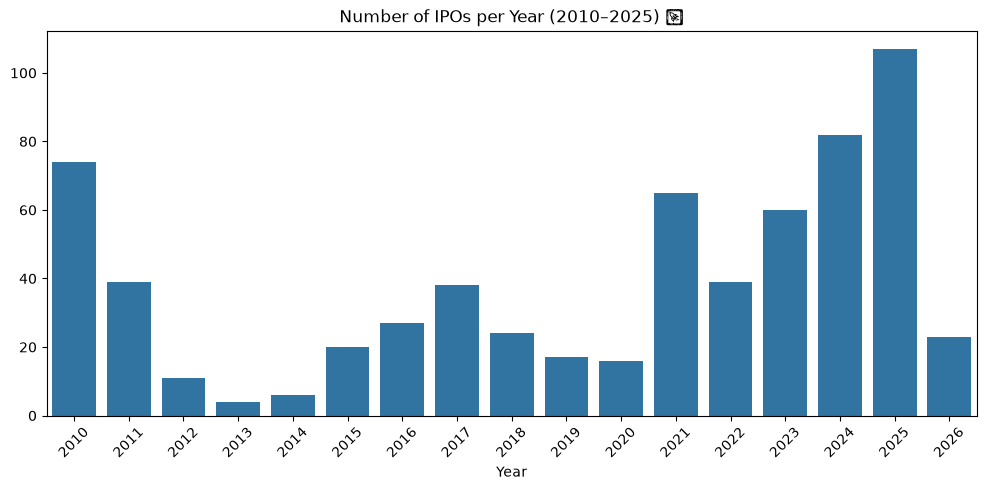

In [14]:
plt.figure(figsize=(12,5))
ipo_count = df['Year'].value_counts().sort_index()
sns.barplot(x=ipo_count.index, y=ipo_count.values)
plt.title("Number of IPOs per Year (2010–2025) 🚀")
plt.xticks(rotation=45)
plt.show()

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


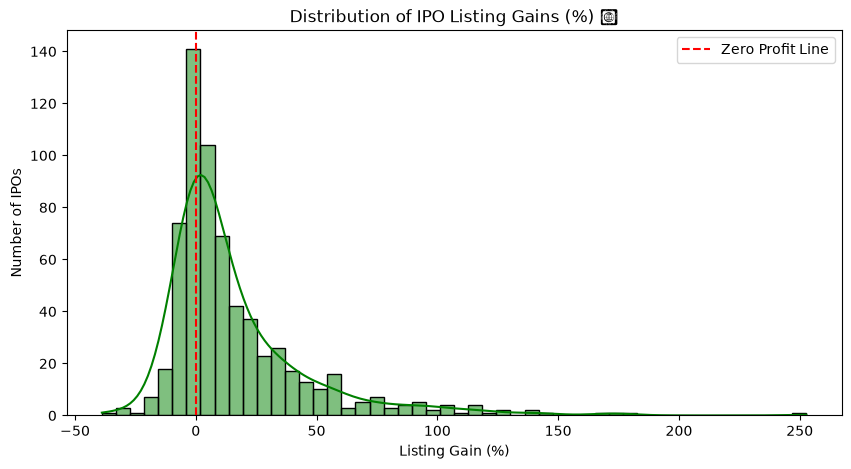

In [21]:


plt.figure(figsize=(10, 5))
sns.histplot(
    df["Listing Gain"], bins=50, kde=True, color="green"
)  # Adjust column name if yours is 'Listing Gain (%)'
plt.title("Distribution of IPO Listing Gains (%) 📈")
plt.xlabel("Listing Gain (%)")
plt.ylabel("Number of IPOs")
plt.axvline(
    0, color="red", linestyle="--", linewidth=1.5, label="Zero Profit Line"
)
plt.legend()
plt.show()

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


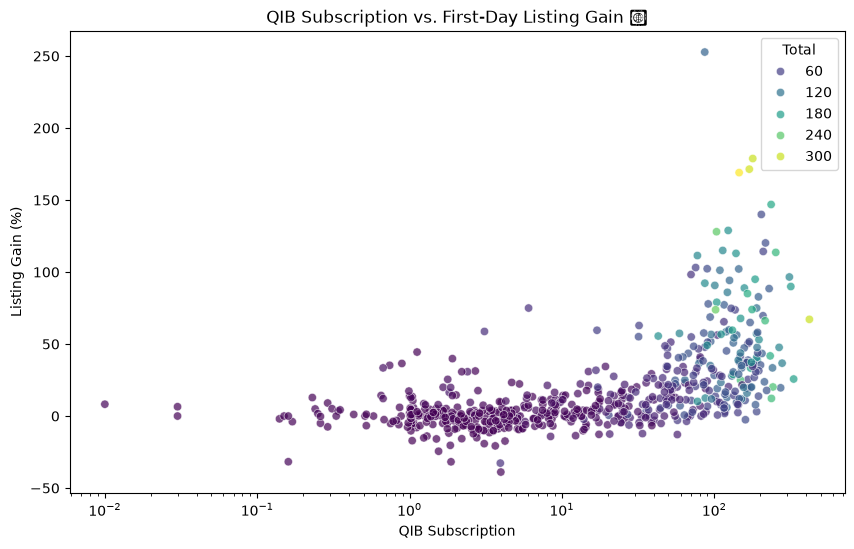

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="QIB",
    y="Listing Gain",
    hue="Total",
    palette="viridis",
    alpha=0.7,
)
plt.title("QIB Subscription vs. First-Day Listing Gain 💰")
plt.xlabel("QIB Subscription")
plt.ylabel("Listing Gain (%)")
plt.xscale("log")  # Using log scale because QIB values can vary wildly
plt.show()

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


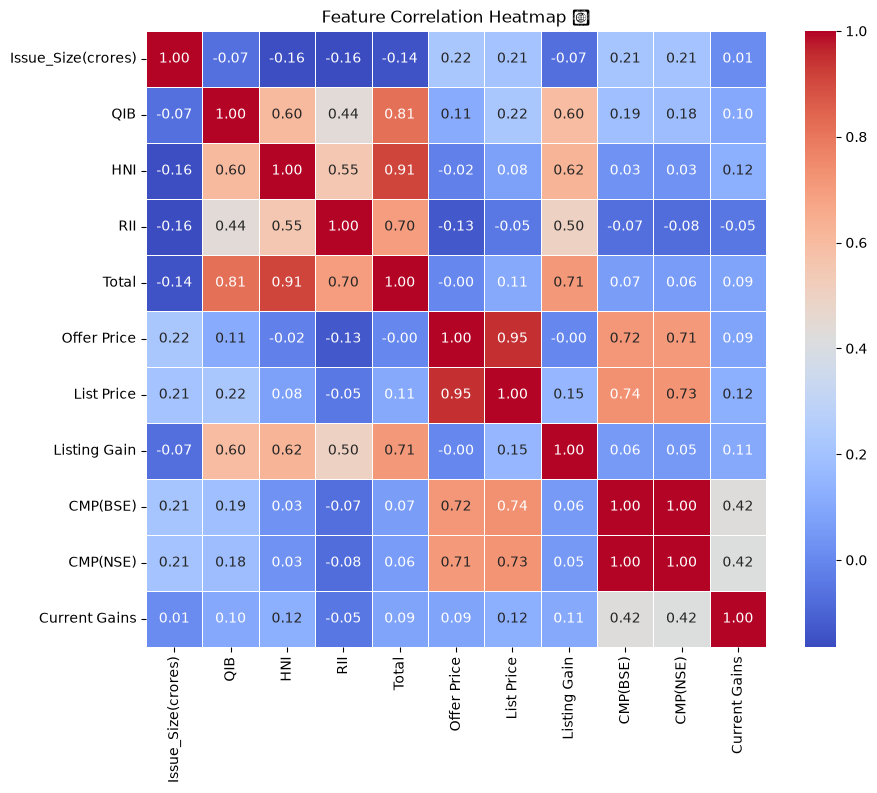

In [23]:
plt.figure(figsize=(10, 8))
# Select only numeric columns
numeric_df = df.select_dtypes(include=["float64", "int64"])
correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Feature Correlation Heatmap 🔍")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13820\3905785332.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_size.index, y=avg_size.values, palette="Blues_d")
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


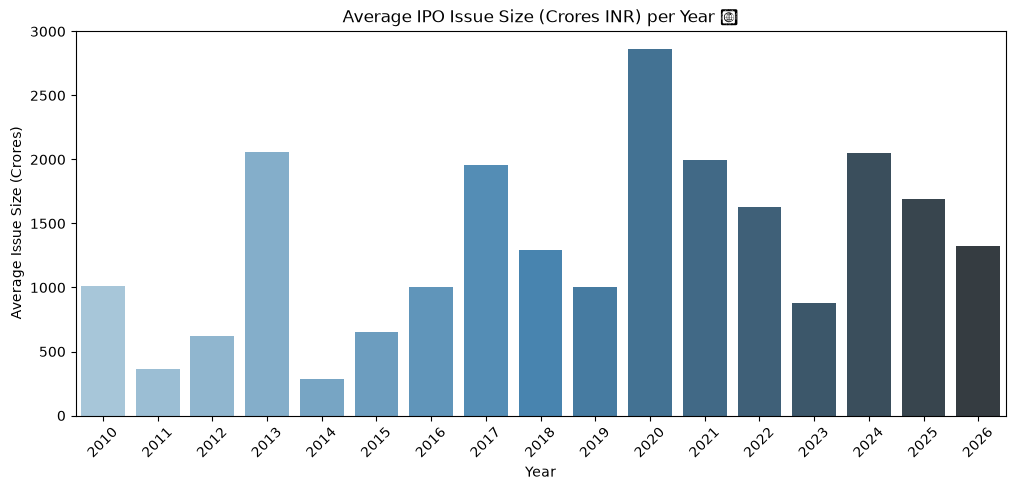

In [26]:
plt.figure(figsize=(12, 5))
# Assuming you extracted a 'Year' column from the 'Date' field
avg_size = df.groupby("Year")["Issue_Size(crores)"].mean()

sns.barplot(x=avg_size.index, y=avg_size.values, palette="Blues_d")
plt.title("Average IPO Issue Size (Crores INR) per Year 📊")
plt.xlabel("Year")
plt.ylabel("Average Issue Size (Crores)")
plt.xticks(rotation=45)
plt.show()